In [1]:
import sys
!"{sys.executable}" -m pip install --upgrade "Pillow==11.1.0"


Defaulting to user installation because normal site-packages is not writeable
  Using cached pillow-11.1.0-cp313-cp313-win_amd64.whl.metadata (9.3 kB)
Using cached pillow-11.1.0-cp313-cp313-win_amd64.whl (2.6 MB)
  Attempting uninstall: Pillow
    Found existing installation: pillow 12.0.0
    Uninstalling pillow-12.0.0:
      Successfully uninstalled pillow-12.0.0



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import sys; sys.path.append("..")

In [3]:
'''
Because of the sheer size of the datasets, the script was only allowed to 
run for enough time to populate the "fake" and "real" folders in the train dataset with approx. 300-500 MB of images each.
'''

import os
from tqdm import tqdm
from datasets import load_dataset
from modelscope.msdatasets import MsDataset


def download_split_openfake(split_name, base_dir):
    print(f"\n Downloading OpenFake '{split_name}' split images")
    dataset = load_dataset("ComplexDataLab/OpenFake", split=split_name, streaming=True)

    # Output folders
    real_dir = os.path.join(base_dir, split_name, "real")
    fake_dir = os.path.join(base_dir, split_name, "fake")
    os.makedirs(real_dir, exist_ok=True)
    os.makedirs(fake_dir, exist_ok=True)

    for i, sample in enumerate(tqdm(dataset, desc=f"Processing {split_name} split")):
        image = sample["image"]
        label = sample["label"]  # 'real' or 'fake'

        # Convert any non-RGB image to RGB
        if image.mode != "RGB":
            image = image.convert("RGB")

        # Choose path based on real or fake
        subdir = real_dir if label == "real" else fake_dir
        image_path = os.path.join(subdir, f"{split_name}_{i:07d}.jpg")

        image.save(image_path)

    print(f"Finished {split_name} split: saved to {os.path.join(base_dir, split_name)}")


def import_openfake():
    base_dir="datasets/OpenFake"

    paths = [
            os.path.join(base_dir, "train", "real"),
            os.path.join(base_dir, "train", "fake"),
            os.path.join(base_dir, "test", "real"),
            os.path.join(base_dir, "test", "fake"),
        ]

    for path in paths:
        os.makedirs(path, exist_ok=True)

    #download_split_openfake("train", base_dir)
    download_split_openfake("test", base_dir)

    print("\n Done. Dataset organized in:")
    print(os.path.abspath(base_dir))

def download_split_wildfake(split_name, base_dir):
    print(f"\n Downloading Wildfake '{split_name}' split images")
    dataset = MsDataset.load('hy2628982280/WildFake', subset_name='default', split=split_name)

    # Output folders
    real_dir = os.path.join(base_dir, split_name, "real")
    fake_dir = os.path.join(base_dir, split_name, "fake")
    os.makedirs(real_dir, exist_ok=True)
    os.makedirs(fake_dir, exist_ok=True)

    for i, sample in enumerate(tqdm(dataset, desc=f"Processing {split_name} split")):
        image = sample["image"]
        label = sample["IsFake"]  # 0 = real, 1 = fake (based on dataset card)


        # Convert RGBA to RGB to avoid JPEG errors
        if image.mode == "RGBA":
            image = image.convert("RGB")

        # Choose path based on real or fake
        subdir = real_dir if label == 0 else fake_dir
        image_path = os.path.join(subdir, f"{split_name}_{i:07d}.jpg")

        image.save(image_path)

    print(f"Finished {split_name} split: saved to {os.path.join(base_dir, split_name)}")

def import_wildfake():
    base_dir="datasets/WildFake"

    paths = [
            os.path.join(base_dir, "train", "real"),
            os.path.join(base_dir, "train", "fake"),
            os.path.join(base_dir, "test", "real"),
            os.path.join(base_dir, "test", "fake"),
        ]

    for path in paths:
        os.makedirs(path, exist_ok=True)

    download_split_wildfake('train', base_dir)
    download_split_wildfake('test', base_dir)
    print("\nDone. Dataset organized in:")
    print(os.path.abspath(base_dir))

def download_split_dragon(dataset_split, split_name, out_dir):
    os.makedirs(out_dir, exist_ok=True)

    for i, sample in enumerate(tqdm(dataset_split, desc=f"Processing {split_name}")):

        # Images are stored under png
        image = sample["png"]
        if image.mode == "RGBA":
            image = image.convert("RGB")

        filename = f"{split_name}_{i:07d}.jpg"
        image.save(os.path.join(out_dir, filename))

def import_dragon():
    base_dir = 'datasets/DRAGON'
    size_split = "ExtraLarge"
    print(f"Downloading DRAGON ({size_split}) subset")
    ds = load_dataset("lesc-unifi/dragon", size_split)

    # Create output directories
    train_dir = os.path.join(base_dir, "train")
    test_dir = os.path.join(base_dir, "test")
    os.makedirs(train_dir, exist_ok=True)
    os.makedirs(test_dir, exist_ok=True)

    download_split_dragon(ds["train"], "train", train_dir)
    download_split_dragon(ds["test"], "test", test_dir)

    print(f"Done. DRAGON ({size_split}) saved in {os.path.abspath(base_dir)}")


def main():
    import_openfake()
    import_wildfake()
    import_dragon()

    return 0


if __name__ == "__main__":
    main()

KeyboardInterrupt: 

## Evaluate Baseline Model

In [3]:
from timm import create_model
import torch.nn as nn

model = create_model("deit_small_patch16_224", pretrained=True)

# Get the number of input features to the final layer 
num_ftrs = model.num_features 

# Create a new classification head with 2 output classes (real, fake)
model.head = nn.Linear(num_ftrs, 2) 

model.eval()
print(model)


VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 384, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (patch_drop): Identity()
  (norm_pre): Identity()
  (blocks): Sequential(
    (0): Block(
      (norm1): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=384, out_features=1152, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (norm): Identity()
        (proj): Linear(in_features=384, out_features=384, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): Identity()
      (drop_path1): Identity()
      (norm2): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=384, out_features=1536, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.0, inplace=False

In [ ]:
# import os
# import random

# train_dir = 'datasets/OpenFake/train'
# real_dir = os.path.join(train_dir, 'real')
# fake_dir = os.path.join(train_dir, 'fake')

# num_images = 1500

# real_images = [os.path.join(real_dir, fname) for fname in os.listdir(real_dir) if fname.endswith(('.jpg', '.png', '.jpeg'))]
# fake_images = [os.path.join(fake_dir, fname) for fname in os.listdir(fake_dir) if fname.endswith(('.jpg', '.png', '.jpeg'))]

# selected_real_images = random.sample(real_images, num_images)
# selected_fake_images = random.sample(fake_images, num_images)

# # Combine them into a list of selected images with their labels
# selected_images = selected_real_images + selected_fake_images
# labels = [0] * num_images + [1] * num_images  


In [ ]:
# import torch
# from torchvision import transforms
# from torch.utils.data import Dataset, DataLoader
# from PIL import Image

# class OpenFakeDataset(Dataset):
#     def __init__(self, image_paths, labels, transform=None):
#         self.image_paths = image_paths
#         self.labels = labels
#         self.transform = transform

#     def __len__(self):
#         return len(self.image_paths)

#     def __getitem__(self, idx):
#         img_path = self.image_paths[idx]
#         image = Image.open(img_path).convert("RGB") 
#         label = self.labels[idx]

#         if self.transform:
#             image = self.transform(image)

#         return image, label

# # Image transformations
# transform = transforms.Compose([
#     transforms.Resize((224, 224)),    # Resize to match ViT's input size
#     transforms.ToTensor(),            # Convert image to tensor
#     transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # Normalize with ImageNet stats that the ViT was trained on
# ])


# dataset = OpenFakeDataset(selected_images, labels, transform=transform)
# dataloader = DataLoader(dataset, batch_size=16, shuffle=True)


In [4]:
import torch
from torch.utils.data import DataLoader

# Use pre-made preprocessing pipeline
from datautil.preproc_dataset import PreprocDataset, collate  # uses preprocess_all internally

# Root directory with 'real' and 'fake' subfolders
train_dir = "datasets/OpenFake/train"

# - walk train_dir/real and train_dir/fake
# - call preprocess_all(path)
# - return a dict with vit / fft_tensor / cnn_patches / meta / label (ONLY USING VIT FOR NOW)
dataset = PreprocDataset(train_dir)

# DataLoader that uses the custom collate function from preprocessing script
dataloader = DataLoader(
    dataset,
    batch_size=16,
    shuffle=True,
    collate_fn=collate,
)


In [5]:
test_dataset = PreprocDataset("datasets/OpenFake/test")
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, collate_fn=collate)

In [7]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 384, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (patch_drop): Identity()
  (norm_pre): Identity()
  (blocks): Sequential(
    (0): Block(
      (norm1): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=384, out_features=1152, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (norm): Identity()
        (proj): Linear(in_features=384, out_features=384, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): Identity()
      (drop_path1): Identity()
      (norm2): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=384, out_features=1536, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.0, inplace=False

100%|██████████| 255/255 [13:16<00:00,  3.12s/it]


Accuracy: 47.33%
Sensitivity (Recall): 0.36
Specificity: 0.58
Positive Predictive Value (PPV): 0.46
Negative Predictive Value (NPV): 0.48
Average Loss: 0.8121

Classification Report:
              precision    recall  f1-score   support

           0       0.48      0.58      0.53      2043
           1       0.46      0.36      0.41      2022

    accuracy                           0.47      4065
   macro avg       0.47      0.47      0.47      4065
weighted avg       0.47      0.47      0.47      4065



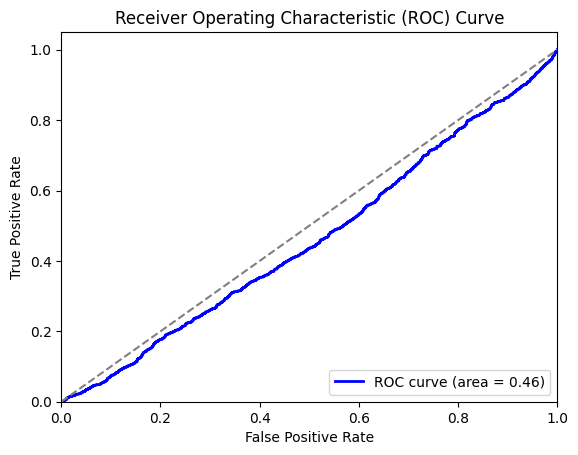

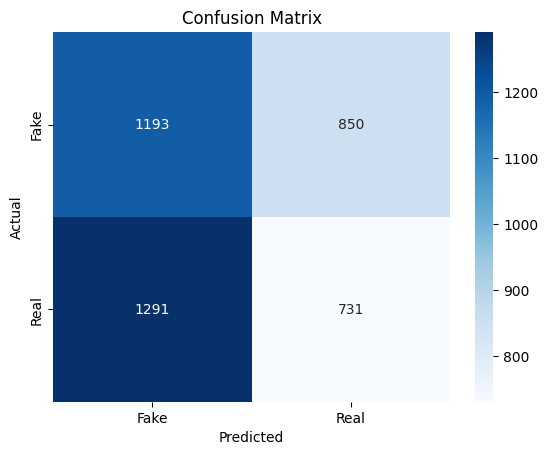

In [ ]:
import torch
import numpy as np
from torch import nn
from tqdm import tqdm
from sklearn.metrics import confusion_matrix, roc_curve, auc, classification_report

# loss function (binary cross-entropy for binary classification)
criterion = nn.CrossEntropyLoss()

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

all_preds = []
all_labels = []
all_probs = []  # hold the probabilities for the ROC curve
running_loss = 0.0

with torch.no_grad():  # No need to track gradients for evaluation
    for batch in tqdm(dataloader):
        # Use the ViT input tensor produced by the project’s preprocessing
        images = batch["vit"].to(device)
        labels = batch["labels"].to(device)

        # Forward pass
        outputs = model(images)

        loss = criterion(outputs, labels)
        running_loss += loss.item()

        # Get predicted class
        _, predicted = torch.max(outputs, 1)

        # Store predictions and labels (for metrics calculation)
        all_preds.append(predicted.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

        # Store predicted probabilities for ROC curve
        probs = torch.softmax(outputs, dim=1)
        all_probs.append(probs.cpu().numpy()[:, 1])  # probs for class 1


all_preds = np.concatenate(all_preds)
all_labels = np.concatenate(all_labels)
all_probs = np.concatenate(all_probs)

# Confusion matrix
tn, fp, fn, tp = confusion_matrix(all_labels, all_preds).ravel()

# Additional metrics
accuracy = (tp + tn) / (tp + tn + fp + fn)
sensitivity = tp / (tp + fn) 
specificity = tn / (tn + fp)
ppv = tp / (tp + fp)  
npv = tn / (tn + fn)  

# ROC curve and AUC
fpr, tpr, thresholds = roc_curve(all_labels, all_probs) 
roc_auc = auc(fpr, tpr)

print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"Sensitivity (Recall): {sensitivity:.2f}")
print(f"Specificity: {specificity:.2f}")
print(f"Positive Predictive Value (PPV): {ppv:.2f}")
print(f"Negative Predictive Value (NPV): {npv:.2f}")
print(f"Average Loss: {running_loss / len(dataloader):.4f}")

print("\nClassification Report:")
print(classification_report(all_labels, all_preds))

# Plot ROC
import matplotlib.pyplot as plt
plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

# Plot confusion matrix
import seaborn as sns
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Fake", "Real"], yticklabels=["Fake", "Real"])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()


In [8]:
## Freeze Backbone and Retest

In [16]:
# ================================
# FROZEN-BACKBONE FEATURE EXTRACTION
# ================================
import torch
from tqdm import tqdm
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
)

# Freeze the backbone (to NOT update ViT weights)
for param in model.parameters():
    param.requires_grad = False

# Unfreeze ONLY the classification head (2-class layer)
for param in model.head.parameters():
    param.requires_grad = True

# Optimizer only sees the head parameters
optimizer = torch.optim.Adam(model.head.parameters(), lr=1e-3)

num_epochs = 3
model.to(device)

print("=== Training with FROZEN backbone (feature extraction) ===")
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    running_corrects = 0
    total_samples = 0

    for batch in tqdm(dataloader, desc=f"Epoch {epoch+1}/{num_epochs}"):
        images = batch["vit"].to(device)       # ViT input from PreprocDataset
        labels = batch["labels"].to(device)    # labels from PreprocDataset

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # stats
        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        running_corrects += (preds == labels).sum().item()
        total_samples += labels.size(0)

    epoch_loss = running_loss / total_samples
    epoch_acc = running_corrects / total_samples * 100
    print(f"Epoch {epoch+1}/{num_epochs} - Loss: {epoch_loss:.4f}, Acc: {epoch_acc:.2f}%")

# ================================
# Evaluation (still frozen backbone)
# ================================
model.eval()
all_labels = []
all_preds = []
all_probs = []
eval_loss = 0.0
total_samples = 0

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Evaluating (frozen backbone)"):
        images = batch["vit"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        eval_loss += loss.item() * images.size(0)
        total_samples += labels.size(0)

        probs = torch.softmax(outputs, dim=1)[:, 1]
        preds = outputs.argmax(dim=1)

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

avg_loss = eval_loss / total_samples
acc = accuracy_score(all_labels, all_preds)

cm = confusion_matrix(all_labels, all_preds)
tn, fp, fn, tp = cm.ravel()
sensitivity = tp / (tp + fn + 1e-8)  # recall for class 1
specificity = tn / (tn + fp + 1e-8)
ppv = tp / (tp + fp + 1e-8)          # precision for class 1
npv = tn / (tn + fn + 1e-8)

print("\n=== Frozen-backbone results (feature extraction) ===")
print(f"Accuracy: {acc * 100:.2f}%")
print(f"Sensitivity (Recall): {sensitivity:.2f}")
print(f"Specificity: {specificity:.2f}")
print(f"Positive Predictive Value (PPV): {ppv:.2f}")
print(f"Negative Predictive Value (NPV): {npv:.2f}")
print(f"Average Loss: {avg_loss:.4f}\n")

print("Classification Report:")
print(classification_report(all_labels, all_preds, digits=4))


=== Training with FROZEN backbone (feature extraction) ===


Epoch 1/3: 100%|██████████| 255/255 [07:31<00:00,  1.77s/it]


Epoch 1/3 - Loss: 0.0041, Acc: 99.98%


Epoch 2/3: 100%|██████████| 255/255 [07:06<00:00,  1.67s/it]


Epoch 2/3 - Loss: 0.0011, Acc: 100.00%


Epoch 3/3: 100%|██████████| 255/255 [07:06<00:00,  1.67s/it]


Epoch 3/3 - Loss: 0.0006, Acc: 100.00%


Evaluating (frozen backbone): 100%|██████████| 152/152 [04:20<00:00,  1.71s/it]


=== Frozen-backbone results (feature extraction) ===
Accuracy: 84.21%
Sensitivity (Recall): 0.85
Specificity: 0.84
Positive Predictive Value (PPV): 0.84
Negative Predictive Value (NPV): 0.84
Average Loss: 0.8684

Classification Report:
              precision    recall  f1-score   support

           0     0.8409    0.8381    0.8395      1192
           1     0.8433    0.8461    0.8447      1228

    accuracy                         0.8421      2420
   macro avg     0.8421    0.8421    0.8421      2420
weighted avg     0.8421    0.8421    0.8421      2420



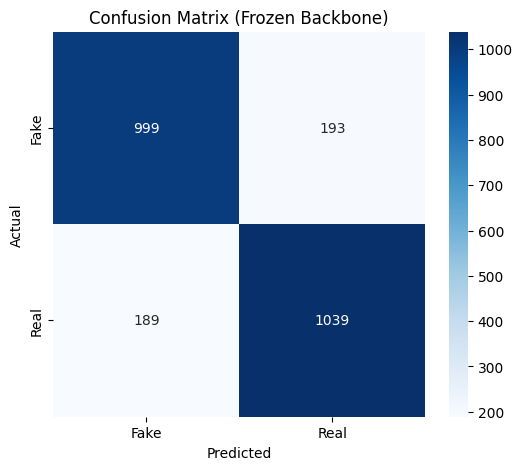

In [17]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Fake", "Real"],
    yticklabels=["Fake", "Real"]
)
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.title("Confusion Matrix (Frozen Backbone)")
plt.show()


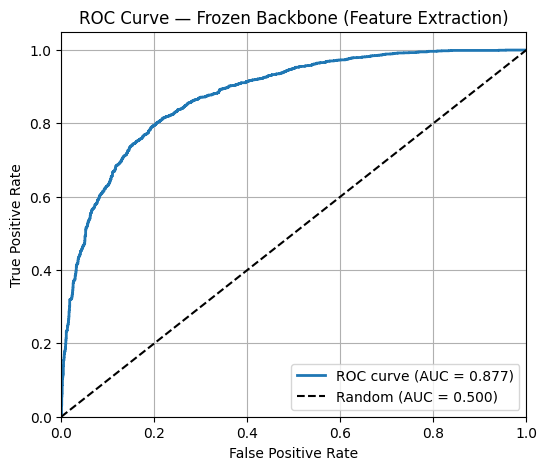

In [12]:
fpr, tpr, _ = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.3f})", linewidth=2)
plt.plot([0, 1], [0, 1], "k--", label="Random (AUC = 0.500)")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Frozen Backbone (Feature Extraction)")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

In [ ]:
## Unfrozen backbone

Unfreezing entire ViT backbone...

=== Training UNFROZEN backbone (fine-tuning) ===

Epoch 1/2


100%|██████████| 255/255 [15:09<00:00,  3.57s/it]


Fine-Tune Loss: 0.1530, Acc: 94.83%

Epoch 2/2


100%|██████████| 255/255 [16:27<00:00,  3.87s/it]


Fine-Tune Loss: 0.0479, Acc: 99.19%

=== Evaluating fine-tuned model ===


100%|██████████| 152/152 [04:41<00:00,  1.85s/it]



=== Fine-Tuned Results ===
Accuracy: 84.30%
Sensitivity: 0.85
Specificity: 0.83
PPV: 0.84
NPV: 0.85
Average Loss: 0.4253

Classification Report:
              precision    recall  f1-score   support

           0     0.8458    0.8331    0.8394      1192
           1     0.8403    0.8526    0.8464      1228

    accuracy                         0.8430      2420
   macro avg     0.8431    0.8428    0.8429      2420
weighted avg     0.8430    0.8430    0.8429      2420



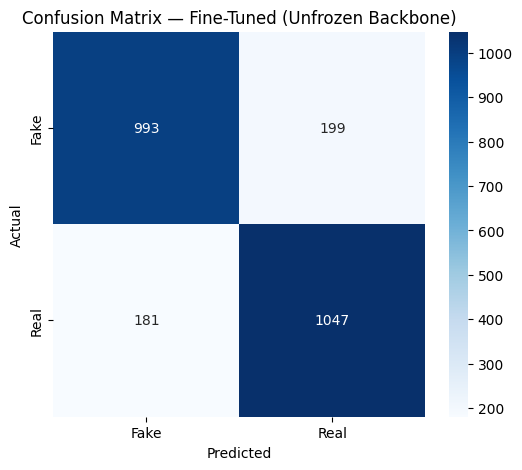


Done! Compare this with your frozen-backbone results.


In [10]:
############################################################
# UNFROZEN BACKBONE — FULL FINE-TUNING 
############################################################

import torch
from torch import nn
import numpy as np
from torch.optim import AdamW
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

# =====================
# Unfreeze backbone
# =====================
print("Unfreezing entire ViT backbone...")
for param in model.parameters():
    param.requires_grad = True

# ====================================
# Define optimizer for full model
# ====================================
optimizer = AdamW(model.parameters(), lr=1e-5, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()

fine_tune_epochs = 2
model.to(device)

# =============================
# Fine-tuning training loop
# =============================
print("\n=== Training UNFROZEN backbone (fine-tuning) ===")

for epoch in range(fine_tune_epochs):
    model.train()
    running_loss = 0
    running_correct = 0
    total_samples = 0

    print(f"\nEpoch {epoch+1}/{fine_tune_epochs}")

    for batch in tqdm(dataloader):
        images = batch["vit"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        running_correct += (preds == labels).sum().item()
        total_samples += labels.size(0)

    epoch_loss = running_loss / total_samples
    epoch_acc = running_correct / total_samples * 100
    print(f"Fine-Tune Loss: {epoch_loss:.4f}, Acc: {epoch_acc:.2f}%")


# ============================
# Evaluate fine-tuned model
# ============================
print("\n=== Evaluating fine-tuned model ===")

model.eval()
all_labels_ft = []
all_preds_ft = []
all_probs_ft = []
eval_loss = 0
total_samples = 0

with torch.no_grad():
    for batch in tqdm(test_loader):
        images = batch["vit"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        eval_loss += loss.item() * images.size(0)
        total_samples += labels.size(0)

        probs = torch.softmax(outputs, dim=1)[:, 1]
        preds = outputs.argmax(dim=1)

        all_labels_ft.extend(labels.cpu().numpy())
        all_preds_ft.extend(preds.cpu().numpy())
        all_probs_ft.extend(probs.cpu().numpy())

avg_loss = eval_loss / total_samples
acc = accuracy_score(all_labels_ft, all_preds_ft)

cm = confusion_matrix(all_labels_ft, all_preds_ft)
tn, fp, fn, tp = cm.ravel()

sensitivity = tp / (tp + fn + 1e-8)
specificity = tn / (tn + fp + 1e-8)
ppv = tp / (tp + fp + 1e-8)
npv = tn / (tn + fn + 1e-8)

print("\n=== Fine-Tuned Results ===")
print(f"Accuracy: {acc * 100:.2f}%")
print(f"Sensitivity: {sensitivity:.2f}")
print(f"Specificity: {specificity:.2f}")
print(f"PPV: {ppv:.2f}")
print(f"NPV: {npv:.2f}")
print(f"Average Loss: {avg_loss:.4f}\n")
print("Classification Report:")
print(classification_report(all_labels_ft, all_preds_ft, digits=4))


# ====================
# Confusion Matrix
# ====================
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Fake", "Real"],
    yticklabels=["Fake", "Real"]
)
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.title("Confusion Matrix — Fine-Tuned (Unfrozen Backbone)")
plt.show()

print("\nDone! Compare this with your frozen-backbone results.")


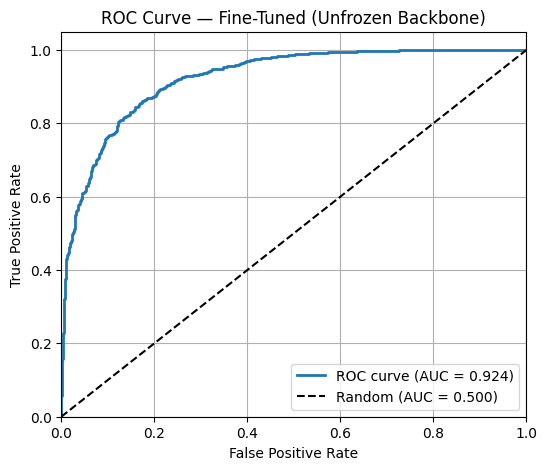

In [12]:
from sklearn.metrics import confusion_matrix, roc_curve, auc, classification_report

fpr_ft, tpr_ft, _ = roc_curve(all_labels_ft, all_probs_ft)
roc_auc_ft = auc(fpr_ft, tpr_ft)

plt.figure(figsize=(6, 5))
plt.plot(fpr_ft, tpr_ft, label=f"ROC curve (AUC = {roc_auc_ft:.3f})", linewidth=2)
plt.plot([0, 1], [0, 1], "k--", label="Random (AUC = 0.500)")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Fine-Tuned (Unfrozen Backbone)")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()